In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
import os
import ssl
from glob import glob
import random

import torchvision.transforms.functional as F

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import joblib  # Để lưu mô hình chuẩn hóa
import json

## kiểm tra cuda

In [59]:
print("Có GPU không? :", torch.cuda.is_available())  # Phải trả về True
print("Phiên bản CUDA trong PyTorch:", torch.version.cuda)
print("Tên GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Không có GPU")

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng: {device}") # phải là: Đang sử dụng: cuda

Có GPU không? : True
Phiên bản CUDA trong PyTorch: 11.8
Tên GPU: NVIDIA GeForce GTX 1650
Đang sử dụng: cuda


## load dữ liệu và chia ngẫu nhiên theo tỉ lệ 90:5:5

In [62]:
# Định nghĩa đường dẫn thư mục chứa dữ liệu
data_dir = "data/cic_ddos_2019_images"
train_data, valid_data, test_data = [], [], []
label_map = {}  # Mapping nhãn -> số


for label_idx, label in enumerate(os.listdir(data_dir)):
    label_path = os.path.join(data_dir, label)
    if not os.path.isdir(label_path):
        continue
    
    # Lưu ánh xạ nhãn
    label_map[label] = label_idx
    
    # Lấy danh sách ảnh
    image_paths = glob(os.path.join(label_path, "*"))
    random.shuffle(image_paths)
    
    # Chia tập dữ liệu theo tỷ lệ 90:5:5
    ratito_1 = 0.9
    ratito_2 = 0.05

    total = len(image_paths)
    train_split = int(ratito_1 * total)
    valid_split = int((ratito_1+ratito_2) * total)

    train_data.extend([(p, label_idx) for p in image_paths[:train_split]])
    valid_data.extend([(p, label_idx) for p in image_paths[train_split:valid_split]])
    test_data.extend([(p, label_idx) for p in image_paths[valid_split:]])

In [22]:
# Kiểm tra số lượng mẫu mỗi tập
print(f"Train: {len(train_data)}, Valid: {len(valid_data)}, Test: {len(test_data)}")

# Hiển thị một số đường dẫn ảnh từ mỗi tập (kiểm tra kết quả)
print("Sample train images:", train_data[:3])
print("Sample valid images:", valid_data[:3])
print("Sample test images:", test_data[:3])
print("labels: ", label_map)

Train: 36000, Valid: 2000, Test: 2000
Sample train images: [('data/cic_ddos_2019_images\\BENIGN\\3592.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\1316.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\3915.png', 0)]
Sample valid images: [('data/cic_ddos_2019_images\\BENIGN\\3149.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\3806.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\3653.png', 0)]
Sample test images: [('data/cic_ddos_2019_images\\BENIGN\\3633.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\2186.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\4490.png', 0)]
labels:  {'BENIGN': 0, 'LDAP': 1, 'MSSQL': 2, 'NetBIOS': 3, 'Portmap': 4, 'Syn': 5, 'UDP': 6, 'UDPLag': 7}


## train

In [ ]:
# Định nghĩa Dataset
class ImageDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [63]:
# Định nghĩa các phép biến đổi dữ liệu
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize ảnh về kích thước chuẩn
    transforms.ToTensor(), # Chuyển ảnh thành tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Chuẩn hóa theo ImageNet
])

# Tạo DataLoader
batch_size = 32 # số lượng mẫu được đưa vào mô hình trong 1 lần huấn luyện
train_loader = DataLoader(ImageDataset(train_data, transform), batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(ImageDataset(valid_data, transform), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(ImageDataset(test_data, transform), batch_size=batch_size, shuffle=False)

# Số lớp đầu ra
num_classes = len(label_map.keys())
print(num_classes)

8


In [64]:
# Kiểm tra thiết bị (GPU nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [65]:
# Sử dụng khi thuê GPU trên máy ảo để tải base model
ssl._create_default_https_context = ssl._create_unverified_context

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

In [ ]:
# # Load mô hình ResNet50 đã pretrain
# num_ftrs = model.fc.in_features
# model.fc = nn.Sequential(
#     nn.Linear(num_ftrs, 1024),  
#     nn.ReLU(),
#     nn.Dropout(0.3),  # Thêm Dropout để giảm overfitting
#     nn.Linear(1024, num_classes)
# )
# model = model.to(device)

# Load mô hình ResNet50 đã pretrain
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(label_map.keys()))  # Adjust output layer
model = model.to(device)

In [ ]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)  

# # Loss and optimizer
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.fc.parameters(), lr=0.001, weight_decay=1e-5)  

In [68]:
# Training function
def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=10):
    train_losses, valid_losses, train_accs, valid_accs = [], [], [], []
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_losses.append(running_loss / len(train_loader))
        train_accs.append(correct / total)
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        valid_losses.append(val_loss / len(valid_loader))
        valid_accs.append(val_correct / val_total)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_losses[-1]:.4f} - Valid Loss: {valid_losses[-1]:.4f} - Train Acc: {train_accs[-1]:.4f} - Valid Acc: {valid_accs[-1]:.4f}")
    return train_losses, valid_losses, train_accs, valid_accs

In [69]:
# Train model
train_losses, valid_losses, train_accs, valid_accs = train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=10)

Epoch 1/10 - Train Loss: 1.1034 - Valid Loss: 2.5763 - Train Acc: 0.6090 - Valid Acc: 0.5750
Epoch 2/10 - Train Loss: 0.3685 - Valid Loss: 0.5813 - Train Acc: 0.8764 - Valid Acc: 0.8750
Epoch 3/10 - Train Loss: 0.2615 - Valid Loss: 0.1894 - Train Acc: 0.9167 - Valid Acc: 0.9125
Epoch 4/10 - Train Loss: 0.1793 - Valid Loss: 0.1378 - Train Acc: 0.9382 - Valid Acc: 0.9500
Epoch 5/10 - Train Loss: 0.1202 - Valid Loss: 0.1117 - Train Acc: 0.9597 - Valid Acc: 0.9750
Epoch 6/10 - Train Loss: 0.0530 - Valid Loss: 0.1264 - Train Acc: 0.9833 - Valid Acc: 0.9500
Epoch 7/10 - Train Loss: 0.0601 - Valid Loss: 0.0786 - Train Acc: 0.9778 - Valid Acc: 0.9750
Epoch 8/10 - Train Loss: 0.0299 - Valid Loss: 0.0903 - Train Acc: 0.9924 - Valid Acc: 0.9875
Epoch 9/10 - Train Loss: 0.1107 - Valid Loss: 0.6254 - Train Acc: 0.9639 - Valid Acc: 0.8750
Epoch 10/10 - Train Loss: 0.1010 - Valid Loss: 0.1478 - Train Acc: 0.9674 - Valid Acc: 0.9750


In [70]:
# Save trained model
torch.save(model.state_dict(), 'models/cic-ddos2019/resnet50_finetuned.pth')

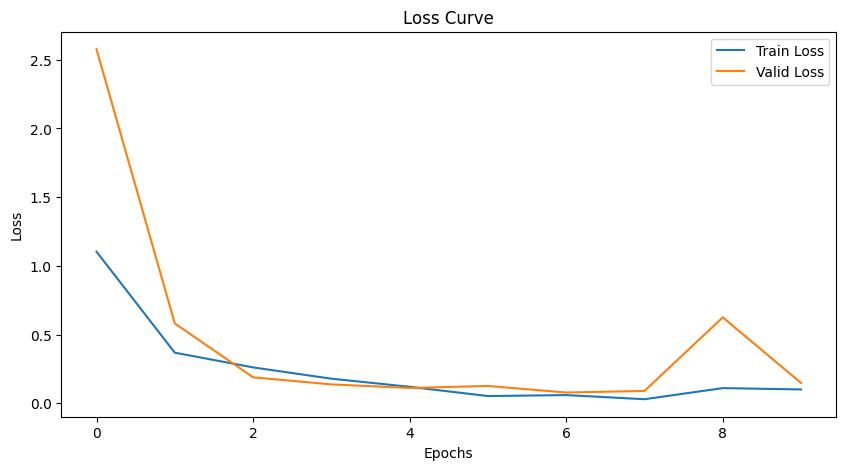

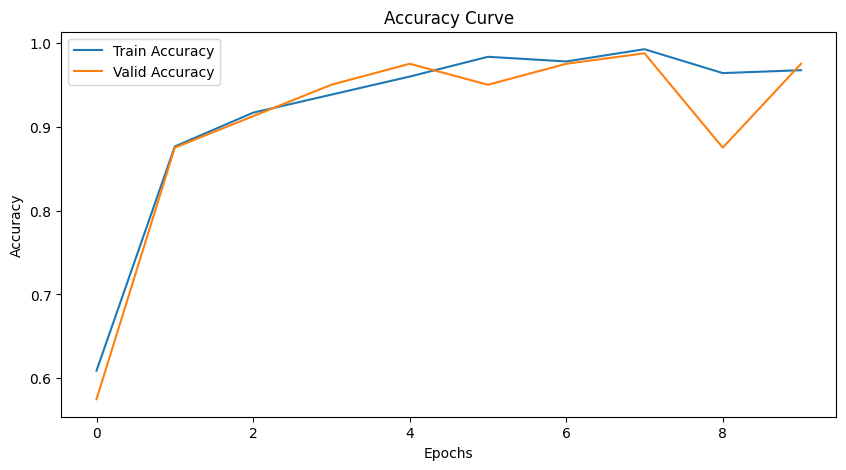

In [71]:
# Plot Loss Curve
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Valid Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

# Plot Accuracy Curve
plt.figure(figsize=(10,5))
plt.plot(train_accs, label='Train Accuracy')
plt.plot(valid_accs, label='Valid Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')
plt.show()


## đánh giá

In [63]:
# Định nghĩa Dataset
class ImageDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [64]:
# Kiểm tra thiết bị (GPU nếu có)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


In [65]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

In [ ]:
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(label_map.keys()))  # Adjust output layer
model = model.to(device)
model.load_state_dict(torch.load("models/cic-ddos2019/resnet50_finetuned.pth",  map_location=torch.device('cpu')))

<All keys matched successfully>

In [8]:
# Định nghĩa các phép biến đổi dữ liệu
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize ảnh về kích thước chuẩn
    transforms.ToTensor(), # Chuyển ảnh thành tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Chuẩn hóa theo ImageNet
])

# Tạo DataLoader
batch_size = 32 # số lượng mẫu được đưa vào mô hình trong 1 lần huấn luyện
test_loader = DataLoader(ImageDataset(test_data, transform), batch_size=batch_size, shuffle=False)

# Số lớp đầu ra
num_classes = len(label_map.keys())
print(num_classes)
print(len(test_data))

8
2000


In [30]:
# Evaluate on test set
def evaluate_model(model, test_loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    return y_true, y_pred

y_true, y_pred = evaluate_model(model, test_loader)

In [31]:
# Tính độ chính xác trên tập test
test_accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.8760


In [32]:
# Classification report
print(classification_report(y_true, y_pred, target_names=label_map.keys()))

              precision    recall  f1-score   support

      BENIGN       0.70      0.83      0.76       250
        LDAP       0.98      0.95      0.96       250
       MSSQL       0.90      0.94      0.92       250
     NetBIOS       0.93      0.90      0.91       250
     Portmap       0.92      0.85      0.88       250
         Syn       0.93      0.77      0.84       250
         UDP       0.94      0.95      0.94       250
      UDPLag       0.77      0.82      0.79       250

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000



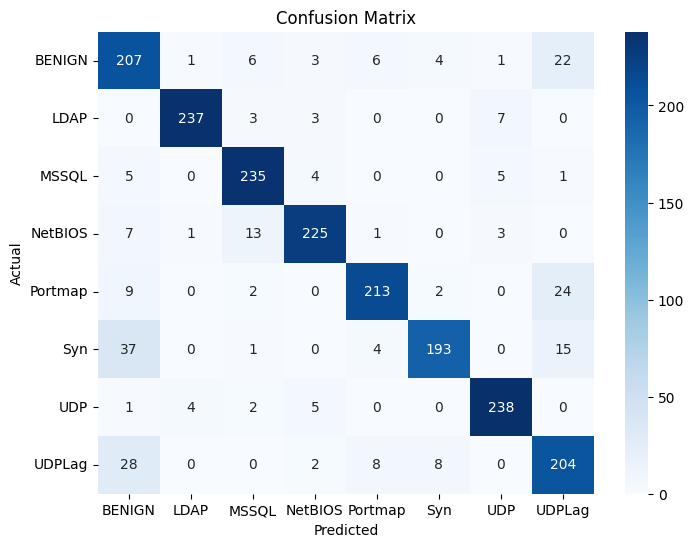

In [33]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


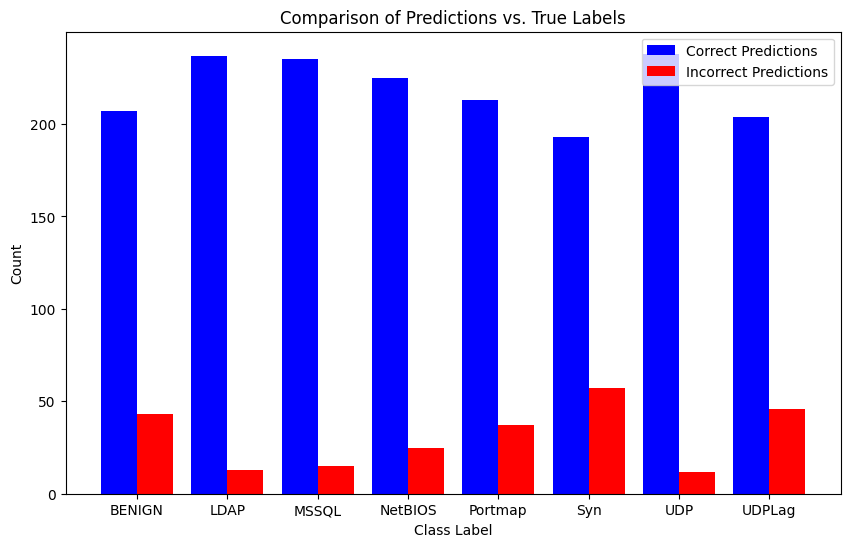

In [34]:
# Plot actual vs predicted labels
# actual_vs_pred_df = pd.DataFrame({'Actual': y_true, 'Predicted': y_pred})
# plt.figure(figsize=(10,6))
# sns.countplot(x='Actual', hue='Predicted', data=actual_vs_pred_df, palette='viridis')
# plt.xlabel('Actual Label')
# plt.ylabel('Count')
# plt.title('Actual vs Predicted Labels')
# plt.legend(title='Predicted Label')
# plt.show()

# Tạo DataFrame chứa nhãn thực tế và dự đoán
df = pd.DataFrame({"True Label": y_true, "Predicted Label": y_pred})

# Đếm số lượng dự đoán đúng và sai theo từng lớp
df["Correct"] = (df["True Label"] == df["Predicted Label"])  # True nếu dự đoán đúng

# Đếm số lượng đúng/sai theo từng lớp
correct_counts = df[df["Correct"]].groupby("True Label").size()
incorrect_counts = df[~df["Correct"]].groupby("True Label").size()

# Đảm bảo tất cả nhãn có trong bảng
correct_counts = correct_counts.reindex(range(num_classes), fill_value=0)
incorrect_counts = incorrect_counts.reindex(range(num_classes), fill_value=0)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.4
index = np.arange(num_classes)

plt.bar(index, correct_counts, bar_width, label="Correct Predictions", color="blue")
plt.bar(index + bar_width, incorrect_counts, bar_width, label="Incorrect Predictions", color="red")

plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Comparison of Predictions vs. True Labels")
plt.xticks(index + bar_width / 2, label_map.keys(), rotation=0)
plt.legend()
plt.show()

In [10]:
# Test individual images
def predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    print(f'Predicted label: {class_names[predicted.item()]}')

In [40]:
predict_image(model, "data/test/SYN/1.png", list(label_map.keys()))
predict_image(model, "data/test/haa/rrr.png", list(label_map.keys()))

# predict_image(model, "data/cic_ddos_2019_images/Syn/4343.png", list(label_map.keys()))

# for i in range(1,31):
#     print(f'image {i}')
#     predict_image(model, f"data/test/SYN/{i}.png", list(label_map.keys()))


Predicted label: MSSQL
Predicted label: LDAP


In [ ]:
def data_to_image(data, img_size=224):
    image_size = (8, 8)
    upscale_factor = 28

    for row in data.values:
        # Chuyển đổi dòng thành ma trận ảnh ban đầu (8x8)
        image_array = np.array(row).reshape(image_size)
        image_array = np.nan_to_num(image_array, nan=0.0, posinf=1.0, neginf=0.0)  # Thay thế giá trị NaN bằng 0

        # Phóng to mỗi pixel np.kron()
        upscale_matrix = np.ones((upscale_factor, upscale_factor))
        enlarged_image_array = np.kron(image_array, upscale_matrix)

        # Chuyển đổi sang ảnh
        image = Image.fromarray((enlarged_image_array * 255).astype(np.uint8))  # Chuyển sang RGB
        image = image.convert("RGB")

        image.save('data/test/haa/r2.png')
    
    return image

selected_columns = ['tot_fwd_pkts','tot_bwd_pkts','totlen_fwd_pkts','totlen_bwd_pkts',
 'fwd_pkt_len_max','fwd_pkt_len_min','fwd_pkt_len_mean','fwd_pkt_len_std',
 'bwd_pkt_len_max','bwd_pkt_len_min','bwd_pkt_len_mean','bwd_pkt_len_std',
 'flow_byts_s','flow_pkts_s','flow_iat_mean','flow_iat_std','flow_iat_max',
 'flow_iat_min','fwd_iat_tot','fwd_iat_mean','fwd_iat_std','fwd_iat_max',
 'fwd_iat_min','bwd_iat_tot','bwd_iat_mean','bwd_iat_std','bwd_iat_max',
 'bwd_iat_min','fwd_psh_flags','bwd_psh_flags','fwd_urg_flags','bwd_urg_flags',
 'fwd_header_len','bwd_header_len','pkt_len_min','pkt_len_max','pkt_len_mean',
 'pkt_len_std','pkt_len_var','pkt_size_avg','fwd_seg_size_avg','bwd_seg_size_avg',
 'fwd_byts_b_avg','fwd_pkts_b_avg','bwd_byts_b_avg','bwd_pkts_b_avg',
 'subflow_fwd_pkts','subflow_fwd_byts','subflow_bwd_pkts','subflow_bwd_byts',
 'init_fwd_win_byts','init_bwd_win_byts','fwd_act_data_pkts','fwd_seg_size_min',
 'active_mean','active_std','active_max','active_min','idle_mean','idle_std',
 'idle_max','idle_min','cwr_flag_cnt','ece_flag_cnt', 'Label']

df_test = pd.read_csv('data/csv/test_syn_flood.csv')
df_test = df_test[selected_columns]


data_normalized = df_test.iloc[[117]] 
data_normalized = data_normalized.drop(columns=['Label']) 

# chuẩn hóa
data_normalized.replace([-np.inf, np.inf], 0, inplace=True)
data_normalized.fillna(data_normalized.mean(), inplace=True)  # Điền giá trị NaN bằng giá trị trung vị


standardScaler = joblib.load("scaler/standardScaler.pkl")
data_normalized = standardScaler.transform(data_normalized)

data_normalized = np.log1p(data_normalized + 1)

data_scaled = pd.DataFrame(MinMaxScaler(feature_range=(0, 255)).fit_transform(data_normalized).astype(np.uint8))

img = data_to_image(data_scaled)

""" Dự đoán nhãn của ảnh đầu vào """
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


if isinstance(img, Image.Image):  # Nếu img là PIL Image, chuyển sang Tensor
    img = F.to_tensor(img)

img_tensor = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(img_tensor)


predicted_class = torch.argmax(output, dim=1).item()
    
print(f'Predicted label: {predicted_class}')